<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Midterm_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👗 Smart Fashion AI with Neural Networks (Mid Term)

**Total Marks: 100 (Theory: 10 | Practical: 90)**  


---

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!

In [ ]:
# Enter your course email here
student_email = "alfattaulislamss@gmail.com" # Example: "your.name@university.edu"

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


---

## Question 1: Theory (10 Marks)

### Part A (3 Marks)
Explain the difference between **Sigmoid** and **ReLU** activation functions. Why is ReLU preferred in hidden layers of deep networks? What problem does Sigmoid cause during backpropagation in deep networks?

### Part B (4 Marks)
In the context of **Gradient Descent**:
- What is the difference between **Batch Gradient Descent**, **Stochastic Gradient Descent (SGD)**, and **Mini-batch Gradient Descent**?
- State one advantage and one disadvantage of each.
- Which type would you recommend for training on Fashion-MNIST (60,000 images), and why?

### Part C (3 Marks)
In our Fashion-MNIST problem (10 classes):
1. Why do we use `nn.CrossEntropyLoss` instead of `nn.BCELoss`?
2. Why should we **NOT** put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss`?
3. What does `loss.backward()` do?

*Double-click here to write your answers*

**Part A Answer:**
  - Differences: Sigmoid activation function squizzes the values into the range between 0 and 1. On the other hand the ReLU activation function keeps any positive value positive but converts any negative value to 0.

  - In the deep learning, ReLU performs better than sigmoid because it learns the patterns faster. It has no complex exponentials like sigmoid activation function. Above all, it converts any negative value into 0 which makes it more efficient for deep learning.

  - In the deep learning the sigmoid activation function causes vanishing gradient problem which mainly occurs because the derivative of the sigmoid activation function has a maximum value of 0.25 which becomes really small when it is multiplied across different hidden layers. It becomes so small that the value shrinks the gradient nearly zero and at a certain point the model stops learning.


**Part B Answer:**
- Differences:
   - **Batch Gradient Descent** -
     - Batch Gradient Descent is used when the dataset is small. It computes the error for all the data of the dataset at once. It takes too much memory and time because it computes error for all the data at once.

          **Advantage**: It provides accurate result because it uses entire data in a dataset.

          **Disadvantage**: It requires too much time and memory to calculate errors for large datasets.


  - **Stochastic Gradient Descent (SGD)** -
     - Stochastic Gradient Descent (SGD) is used for large datasets. It computes the error for all the data in a dataset one by one. It provides quicker result than Batch Gradient Descent.

          **Advantage**: It requires less memory because it processes data in a dataset one by one.

          **Disadvantage**: It can provide less precise result because it calculates errors for each data one by one which makes it noisy.

  - **Mini-Batch Gradient Descent** -

     - Mini-Batch Gradient Descent is also used for large dataset but this method computes the error of a dataset as a chunk for example: For a dataset with 100 data it will compute error as 5/10/20 data at once (as a chunk). It provides speed and stability and it is considered the standard gradient descent for calculating error.

        **Advantage**: It updates the weights more often which increases the speed of calculation for the data in a dataset.

        **Disadvantage**: it requires careful tuning of learning rates and batch size together which might be tiresome.

  - Recommendation:
     - I would use Mini Batch gradient Descent for training on Fashion-MNIST (60,000 images) because it processes the data as chunk which are more stable and quicker than other gradients. It is gpu friendly and it requires less memory which makes the calculation faster. Although it can still have some noises compared to Batch Gradient Descent, this can be controlled by tuning the batch size.

**Part C Answer:**

1. We use nn.CrossEntropyLoss because it handles multi-class classification problem. On the other hand nn.BCELoss handles binary classification problem.

   In our Fashion-MNIST problem we use nn.CrossEntropyLoss because the actual result resides in one of the 10 classes and it requires raw, unnormalized scores (logits) directly from the model, and applies Softmax internally itself to convert them into probabilities before computing the loss. The nn.BCELoss is designed for binary classification problems where the results require for an independent result (yes/no) using sigmoid.


2. We should not put nn.Softmax as the last layer because it combines two steps, LogSoftmax which applies softmax internally and takes the log and NLLLoss which computes the loss based on the log.

    It expects raw logits instead of probabilities. If we add nn.Softmax at the last stage we will apply softmax twice because it already applies softmax internally. This double application of softmax is called Double Softmax which may occur problems such as incorrect gradients, numerical instability, wrong loss curves.


3. The loss.backward() triggers backpropagation in neural network which means it computes gradients of the loss with respect to every trainable parameters.

    The pytorch builds a computational graph. When the backpropagation is called pytorch walks backward through this graph and apply chain rule of calculus to all the layers. Then for each parameters it computes the derivatives and observe how much a small change in that parameter would change the loss. Then these gradients are stored in each parameter's .grad attribute.


---

## Question 2: Load & Explore the Data (15 Marks)

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")

Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.
- Display each image in grayscale (`cmap='gray'`)
- Title each subplot with its class name
- Turn off axis ticks

*Hint: loop through classes 0-9, find one sample of each class, and plot it.*

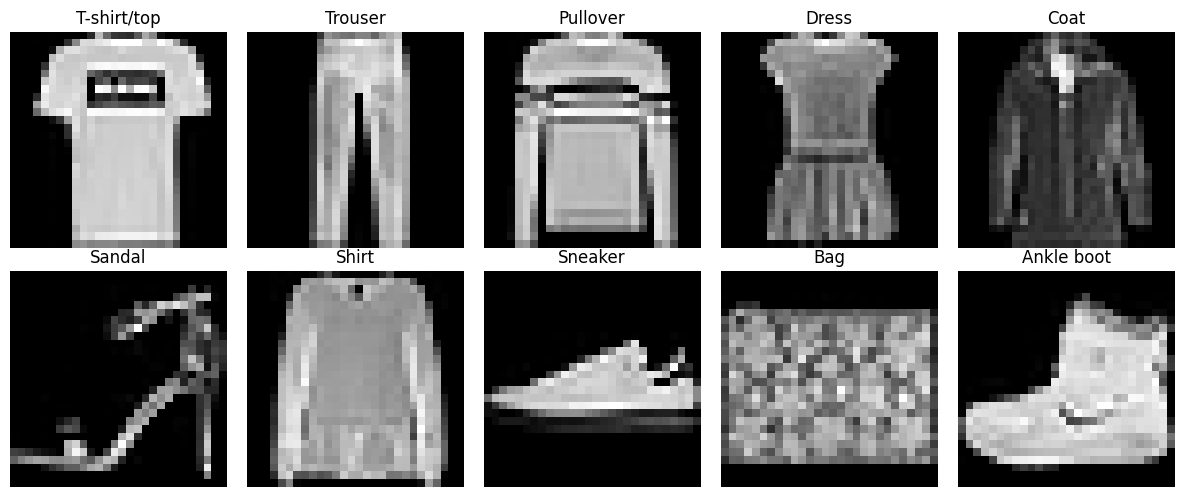

In [4]:
# YOUR CODE HERE
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(0, 10):
  sample = np.where(train_labels_all == i)[0][0]
  images = train_images_all[sample]

  class_row = i // 5
  class_col = i % 5

  ax = axes[class_row, class_col]
  ax.imshow(images, cmap = 'gray')
  ax.set_title(class_names[i])
  ax.axis('off')

plt.tight_layout()
plt.show()

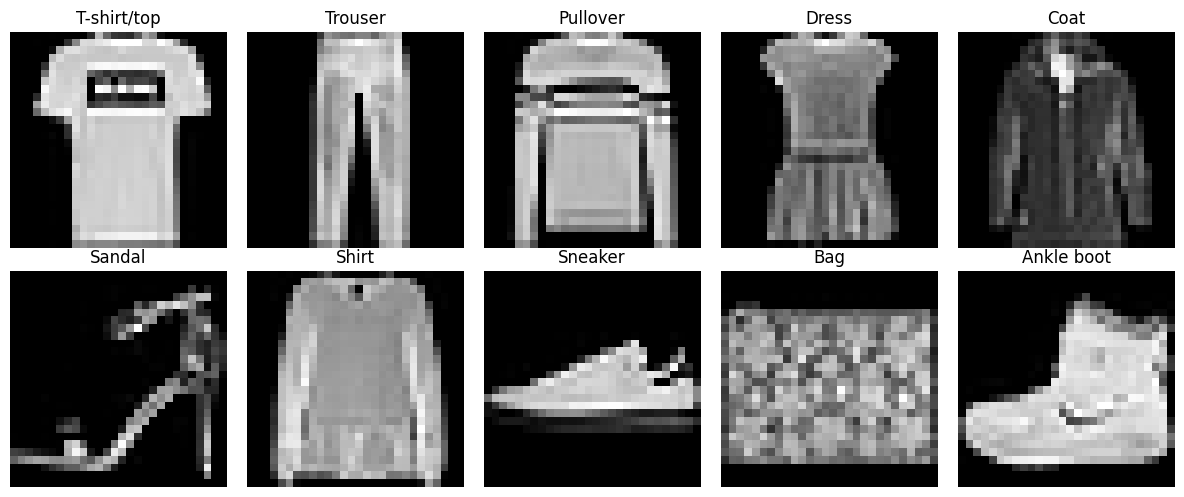

### 2.3 Class Distribution (5 Marks)

Plot a **bar chart** showing how many samples belong to each class in the training set.
- X-axis: class names
- Y-axis: count
- Title: "Training Set Class Distribution"
- Add the count number on top of each bar

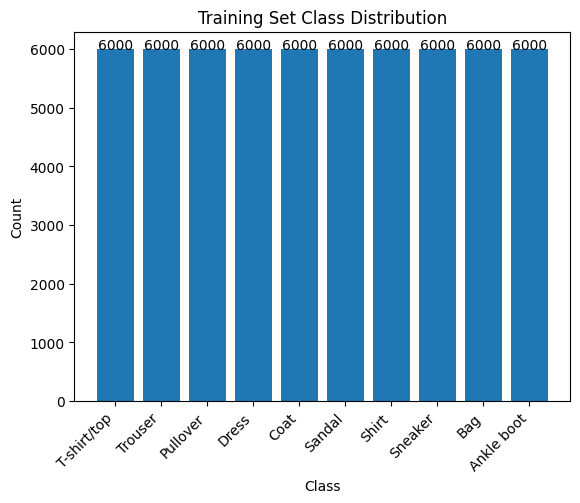

In [10]:
# YOUR CODE HERE
counts = np.bincount(train_labels_all)

for i, count in enumerate(counts):
  plt.text(i, count, str(count), ha = 'center')

plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.show()

### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.



**Your tasks:**
1. Normalize pixel values to **[0, 1]** by dividing by 255.0.
2. Split training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
3. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (tensors), `y_train, y_val, y_test` (tensors)

In [23]:
from sklearn.model_selection import train_test_split

# YOUR CODE HERE
# Normalize pixel values to [0, 1] by dividing by 255.0.
train_img_norm = train_images_all / 255.0
test_img_norm = test_images_all / 255.0

# Split training data into train (50,000) and validation (10,000) using train_test_split with random_state=42.
X = train_img_norm
y = train_labels_all

train_img_split, val_img_split, train_labels_split, val_labels_split = train_test_split(X, y, test_size = 10000, random_state = 42)

# Convert all sets to PyTorch tensors — images as float32, labels as long.
X_train = torch.tensor(train_img_split, dtype = torch.float32)
X_test = torch.tensor(test_img_norm, dtype = torch.float32)
X_val = torch.tensor(val_img_split, dtype = torch.float32)

y_train = torch.tensor(train_labels_split, dtype = torch.long)
y_test = torch.tensor(test_labels_all, dtype = torch.long)
y_val = torch.tensor(val_labels_split, dtype = torch.long)

In [24]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [27]:
# YOUR CODE HERE
# Create TensorDataset and DataLoader objects for the train, validation, and test sets.
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
val_dataset = TensorDataset(X_val, y_val)

# batch_size = 64 shuffle = True for training, False for validation
# Required variables: train_loader, val_loader, test_loader
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = False)

In [28]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |

> **Note**: Do NOT apply Softmax at the output layer.

After defining the class:
1. Create an instance of `FashionClassifier`.
2. Print the model architecture.

In [29]:
# YOUR CODE HERE
# Create a class FashionClassifier inheriting from nn.Module.
# Use nn.Sequential with this architecture:
class FashionClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.network(x)

# Create an instance of FashionClassifier.
model = FashionClassifier()
print(model)

FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [30]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

✅ Q4 Passed!
   Total parameters: 242762
FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [31]:
# YOUR CODE HERE
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)
epochs = 15

### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [34]:
# YOUR CODE HERE
# Train on train_loader and compute training loss
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
  model.train()
  train_loss = 0
  train_correct = 0
  train_total = 0

  for xBatch, yBatch in train_loader:
    # forward pass
    out = model(xBatch)

    # loss calculation
    loss = loss_func(out, yBatch)

    # zero gradient
    optimizer.zero_grad()

    # backpropagation
    loss.backward()

    # parameters update
    optimizer.step()

    train_loss += loss.item() * xBatch.size(0)
    train_correct += (out.argmax(1) == yBatch).sum().item()
    train_total += yBatch.size(0)

  train_losses.append(train_loss / train_total)
  train_accuracies.append(100 * train_correct / train_total)


  # Evaluate on val_loader (with torch.no_grad()) and compute validation loss
  model.eval()
  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for xBatch, yBatch in val_loader:
      # forward pass
      out = model(xBatch)

      # loss calculation
      loss = loss_func(out, yBatch)

      val_loss += loss.item() * xBatch.size(0)
      val_correct += (out.argmax(1) == yBatch).sum().item()
      val_total += yBatch.size(0)

    val_losses.append(val_loss / val_total)
    val_accuracies.append(100 * val_correct / val_total)

    # Print: Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}
    print(f'Epoch: {epoch + 1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')

Epoch: 1/15 | Train Loss: 0.6975 | Val Loss: 0.7378
Epoch: 2/15 | Train Loss: 0.6204 | Val Loss: 0.6131
Epoch: 3/15 | Train Loss: 0.5770 | Val Loss: 0.5802
Epoch: 4/15 | Train Loss: 0.5459 | Val Loss: 0.5576
Epoch: 5/15 | Train Loss: 0.5205 | Val Loss: 0.5276
Epoch: 6/15 | Train Loss: 0.4999 | Val Loss: 0.4999
Epoch: 7/15 | Train Loss: 0.4833 | Val Loss: 0.5985
Epoch: 8/15 | Train Loss: 0.4659 | Val Loss: 0.4914
Epoch: 9/15 | Train Loss: 0.4525 | Val Loss: 0.4923
Epoch: 10/15 | Train Loss: 0.4395 | Val Loss: 0.4672
Epoch: 11/15 | Train Loss: 0.4271 | Val Loss: 0.5524
Epoch: 12/15 | Train Loss: 0.4151 | Val Loss: 0.4372
Epoch: 13/15 | Train Loss: 0.4049 | Val Loss: 0.4437
Epoch: 14/15 | Train Loss: 0.3964 | Val Loss: 0.4359
Epoch: 15/15 | Train Loss: 0.3886 | Val Loss: 0.4063


In [35]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

✅ Q5.2 Passed!
   Final Train Acc: 86.31%, Final Val Acc: 85.89%


### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [36]:
# YOUR CODE HERE
# Evaluate the model on the test set. Print the test_accuracy (required_variable)
model.eval()
all_preds = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():
  for xBatch, yBatch in test_loader:
    # forward pass
    out = model(xBatch)
    predictions = out.argmax(1)

    test_correct += (predictions == yBatch).sum().item()
    test_total += yBatch.size(0)

    # Also, collect all test predictions and true labels into lists called all_preds and all_labels (we'll use them for analysis later).
    all_preds.extend(predictions.tolist())
    all_labels.extend(yBatch.tolist())

test_accuracy = 100 * test_correct / test_total

# Print: Test Accuracy: {:.2f}%
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 85.16%


In [37]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

✅ Q5.3 Passed! Test Accuracy: 85.16%


---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

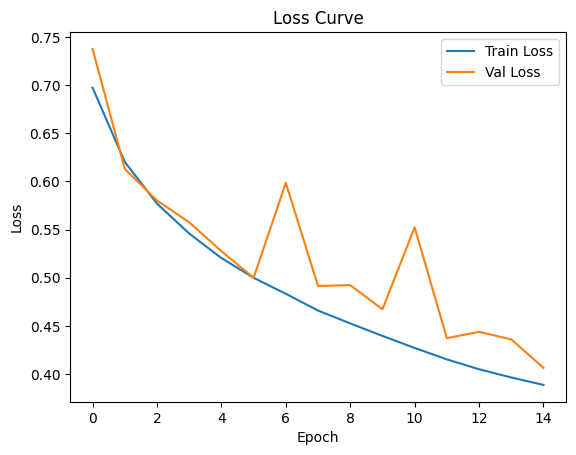

In [38]:
# YOUR CODE HERE
plt.plot(train_losses, label = 'Train Loss')
plt.plot(val_losses, label = 'Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

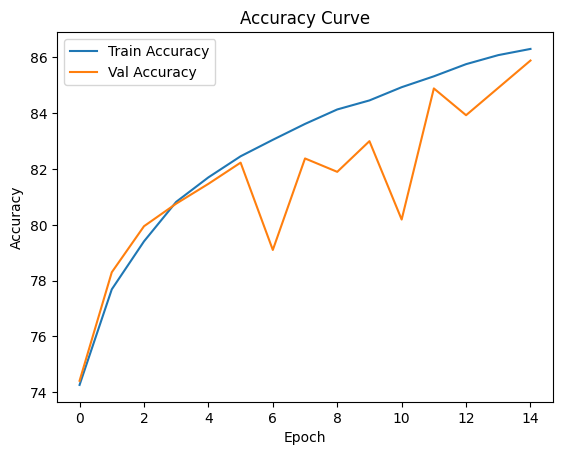

In [39]:
# YOUR CODE HERE
plt.plot(train_accuracies, label = 'Train Accuracy')
plt.plot(val_accuracies, label = 'Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

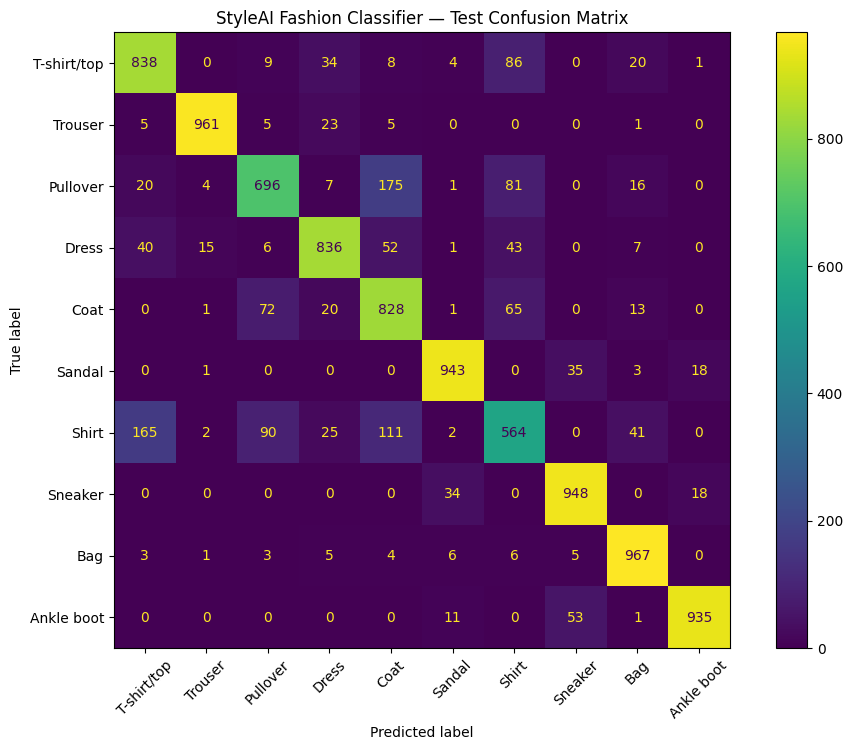

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE
conf_mat = confusion_matrix(all_labels, all_preds)
display = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels = class_names)

fig, ax = plt.subplots(figsize = (12, 8))
display.plot(ax = ax, cmap = 'viridis', xticks_rotation = 45)

plt.title('StyleAI Fashion Classifier — Test Confusion Matrix')
plt.show()

### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [44]:
from sklearn.metrics import classification_report

# YOUR CODE HERE
report = classification_report(all_labels, all_preds, target_names = class_names)
print(f'Classification report: \n {report}')

Classification report: 
               precision    recall  f1-score   support

 T-shirt/top       0.78      0.84      0.81      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.79      0.70      0.74      1000
       Dress       0.88      0.84      0.86      1000
        Coat       0.70      0.83      0.76      1000
      Sandal       0.94      0.94      0.94      1000
       Shirt       0.67      0.56      0.61      1000
     Sneaker       0.91      0.95      0.93      1000
         Bag       0.90      0.97      0.93      1000
  Ankle boot       0.96      0.94      0.95      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**Your Analysis:**

1. By looking at the confusion matrix graph, It appears that the Pullover and Coat are the most confused classes. It predicted 175 Pullovers wrongly as Coat. The Shirt and T-shirt/Top classes are also confused with 165 and 85 wrong predictions. These mistakes occured because the upper garments are mostly identical to each other in respect of their shapes and sleeves and mostly they are 28x28 greyscale image which makes the predictions more weak.

2. The model is neither overfitting nor underfitting. The training and validation loss stay close to each other and they decrease together as well as the accuracies. If it would overfitting we would see the validation loss to rise and the training loss to fall with a large accuracy gap which is not happening here. So it can be said that, this model is not overfitting and also not underfitting.